# Étape 2 - Prétraitement et extraction des features

## Objectifs

- Charger l'index produit à l'étape 1.
- Définir un preprocessing compatible avec un CNN pré-entraîné.
- Extraire des embeddings visuels avec un ResNet18 gelé.
- Sauvegarder une table de features exploitable pour l'étape 3.
- Conserver la séparation entre labels forts et données non labellisées.

## Conventions

- Les labels forts restent dans `label_strong` et `label_strong_name`.
- Les données non annotées conservent `y_ssl = -1`.
- Les embeddings sont produits pour l'ensemble du corpus, mais les usages supervisés et semi-supervisés resteront séparés ensuite.

# Librairies

In [1]:
from __future__ import annotations

from pathlib import Path
import json
import sys
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from torch.utils.data import DataLoader
from torchvision.models import ResNet18_Weights

PROJECT_ROOT_CANDIDATE = Path.cwd().resolve()
for candidate in [PROJECT_ROOT_CANDIDATE, *PROJECT_ROOT_CANDIDATE.parents]:
    if (candidate / "src").exists() and (candidate / "environment.yml").exists():
        if str(candidate) not in sys.path:
            sys.path.append(str(candidate))
        break

from src.notebook_utils import (
    build_figure_saver,
    configure_notebook,
    ensure_directory,
    find_project_root,
    set_global_seed,
)

from src.feature_utils import (
    BrainScanImageDataset,
    build_feature_extractor,
    build_feature_table,
    build_preprocess,
    extract_embeddings,
    infer_embedding_dim,
    show_preprocessing_examples,
)

configure_notebook(display_max_columns=100, display_max_rows=100)


# Paramètres

In [2]:
PROJECT_ROOT = find_project_root()
EDA_INDEX_PATH = PROJECT_ROOT / "data" / "interim" / "image_index.csv"
FEATURE_OUTPUT_DIR = ensure_directory(PROJECT_ROOT / "data" / "processed" / "features")
FIGURES_DIR = ensure_directory(PROJECT_ROOT / "reports" / "figures" / "feature_extraction")

MODEL_NAME = "resnet18"
WEIGHTS = ResNet18_Weights.DEFAULT
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32
NUM_WORKERS = 0
RANDOM_SEED = 42
MAX_IMAGES_TO_PROCESS = None
SAVE_FIGURES = True
SAVE_FEATURE_TABLE = True

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PIN_MEMORY = DEVICE.type == "cuda"

set_global_seed(RANDOM_SEED, torch_module=torch)
save_figure = build_figure_saver(FIGURES_DIR, enabled=SAVE_FIGURES)

print(f"PROJECT_ROOT         : {PROJECT_ROOT}")
print(f"EDA_INDEX_PATH       : {EDA_INDEX_PATH}")
print(f"FEATURE_OUTPUT_DIR   : {FEATURE_OUTPUT_DIR}")
print(f"FIGURES_DIR          : {FIGURES_DIR}")
print(f"MODEL_NAME           : {MODEL_NAME}")
print(f"IMAGE_SIZE           : {IMAGE_SIZE}")
print(f"BATCH_SIZE           : {BATCH_SIZE}")
print(f"NUM_WORKERS          : {NUM_WORKERS}")
print(f"DEVICE               : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"CUDA device          : {torch.cuda.get_device_name(0)}")


PROJECT_ROOT         : /home/maxime/projects/brainscan-semisupervised
EDA_INDEX_PATH       : /home/maxime/projects/brainscan-semisupervised/data/interim/image_index.csv
FEATURE_OUTPUT_DIR   : /home/maxime/projects/brainscan-semisupervised/data/processed/features
FIGURES_DIR          : /home/maxime/projects/brainscan-semisupervised/reports/figures/feature_extraction
MODEL_NAME           : resnet18
IMAGE_SIZE           : (224, 224)
BATCH_SIZE           : 32
NUM_WORKERS          : 0
DEVICE               : cuda
CUDA device          : NVIDIA GeForce RTX 5060 Laptop GPU


## 1. Charger l'index produit pendant l'EDA

On réutilise `image_index.csv` afin de conserver la séparation entre données fortement labellisées et données non annotées.

In [3]:
image_index_df = pd.read_csv(EDA_INDEX_PATH)

image_index_df["is_corrupt"] = image_index_df["is_corrupt"].fillna(False).astype(bool)
image_index_df["file_exists"] = image_index_df["relative_path"].map(lambda path: (PROJECT_ROOT / path).exists())

valid_images_df = image_index_df.loc[~image_index_df["is_corrupt"] & image_index_df["file_exists"]].copy()
valid_images_df = valid_images_df.sort_values("relative_path").reset_index(drop=True)

#? Limitation facultative du nombre d'images à traiter
if MAX_IMAGES_TO_PROCESS is not None:
    valid_images_df = valid_images_df.sample(
        n=min(MAX_IMAGES_TO_PROCESS, len(valid_images_df)),
        random_state=RANDOM_SEED,
    ).sort_values("relative_path").reset_index(drop=True)

# Vue d'ensemble des volumes disponibles dans le dataset
dataset_overview_df = pd.DataFrame(
    {
        "metric": [
            "n_rows_in_image_index",
            "n_valid_images",
            "n_strong_labeled",
            "n_unlabeled",
        ],
        "value": [
            len(image_index_df),
            len(valid_images_df),
            int((valid_images_df["source_split"] == "strong_labeled_pool").sum()),
            int((valid_images_df["source_split"] == "unlabeled_pool").sum()),
        ],
    }
)

# Nombre d'images par pool et par groupe de label
split_summary_df = (
    valid_images_df.groupby(["source_split", "label_group"], dropna=False)
    .size()
    .rename("n_images")
    .reset_index()
    .sort_values(["source_split", "label_group"])
)

display(dataset_overview_df)
display(split_summary_df)
display(valid_images_df[["relative_path", "source_split", "label_group", "label_strong", "y_ssl"]].head(5))


,metric,value
0,n_rows_in_image_index,1506
1,n_valid_images,1506
2,n_strong_labeled,100
3,n_unlabeled,1406


,source_split,label_group,n_images
0,strong_labeled_pool,cancer,50
1,strong_labeled_pool,normal,50
2,unlabeled_pool,unlabeled,1406


,relative_path,source_split,label_group,label_strong,y_ssl
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,cancer,1.0,1
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,cancer,1.0,1
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,cancer,1.0,1
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,cancer,1.0,1
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,cancer,1.0,1


## 2. Préprocessing compatible ResNet18

On conserve les images en `RGB`, on redimensionne en `224 × 224` et on applique la normalisation ImageNet attendue par le modèle pré-entraîné.

In [4]:
preprocess = build_preprocess()

preprocessing_df = pd.DataFrame(
    {
        "parameter": [
            "model_name",
            "weights",
            "resize",
            "normalization_mean",
            "normalization_std",
        ],
        "value": [
            MODEL_NAME,
            str(WEIGHTS),
            str(IMAGE_SIZE),
            str(IMAGENET_MEAN),
            str(IMAGENET_STD),
        ],
    }
)

display(preprocessing_df)

,parameter,value
0,model_name,resnet18
1,weights,ResNet18_Weights.IMAGENET1K_V1
2,resize,"(224, 224)"
3,normalization_mean,"(0.485, 0.456, 0.406)"
4,normalization_std,"(0.229, 0.224, 0.225)"


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/feature_extraction/02_feature_extraction_preprocessing_examples.png


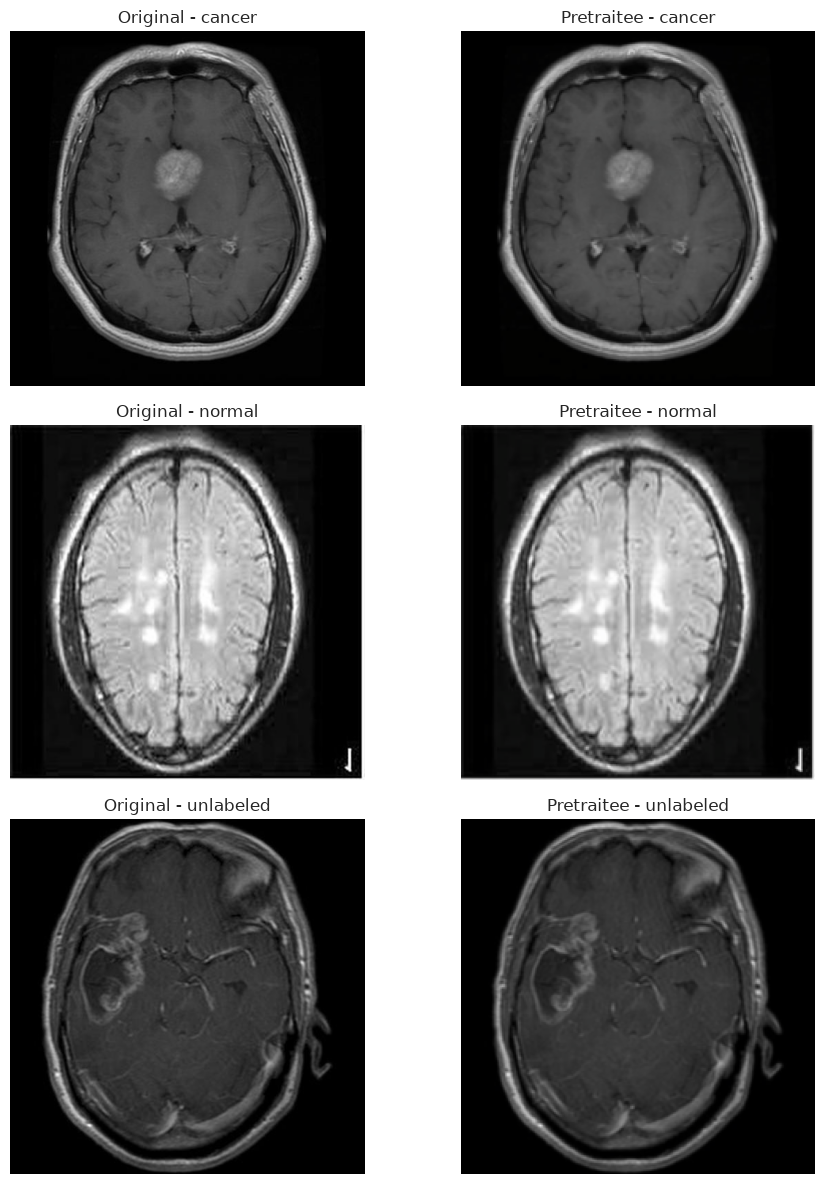

In [5]:
fig = show_preprocessing_examples(
    valid_images_df,
    project_root=PROJECT_ROOT,
    preprocess=preprocess,
    random_seed=RANDOM_SEED,
)

if fig is not None:
    save_figure(fig, "02_feature_extraction_preprocessing_examples")
    plt.show()

## 3. Dataset PyTorch et DataLoader

On prépare ici le flux de lecture des images pour l'extraction des embeddings.

In [6]:
feature_dataset = BrainScanImageDataset(valid_images_df, PROJECT_ROOT, preprocess)
feature_loader = DataLoader(
    feature_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

first_batch = next(iter(feature_loader))
loader_summary_df = pd.DataFrame(
    {
        "parameter": ["dataset_length", "batch_size", "n_batches", "first_batch_shape"],
        "value": [
            len(feature_dataset),
            BATCH_SIZE,
            len(feature_loader),
            str(tuple(first_batch["image"].shape)),
        ],
    }
)

display(loader_summary_df)


,parameter,value
0,dataset_length,1506
1,batch_size,32
2,n_batches,48
3,first_batch_shape,"(32, 3, 224, 224)"


## 4. Modèle pré-entraîné

On utilise `ResNet18` avec poids ImageNet. La tête de classification est retirée afin de récupérer directement les embeddings visuels de dimension fixe.

In [7]:
# On gele le backbone et on supprime la tete de classification pour ne garder que les embeddings.
feature_extractor = build_feature_extractor(weights=WEIGHTS, device=DEVICE)
FEATURE_DIM = infer_embedding_dim(feature_extractor, image_size=IMAGE_SIZE, device=DEVICE)

model_summary_df = pd.DataFrame(
    {
        "parameter": ["model_name", "feature_dim", "trainable_parameters", "device"],
        "value": [
            MODEL_NAME,
            FEATURE_DIM,
            int(sum(parameter.numel() for parameter in feature_extractor.parameters() if parameter.requires_grad)),
            str(DEVICE),
        ],
    }
)

display(model_summary_df)


,parameter,value
0,model_name,resnet18
1,feature_dim,512
2,trainable_parameters,0
3,device,cuda


## 5. Extraction des embeddings

Les embeddings sont extraits sur l'ensemble du corpus. Les métadonnées associées sont conservées pour garder une trace explicite des pools `strong_labeled_pool` et `unlabeled_pool`.

In [8]:
start_time = time.perf_counter()
embedding_metadata_df, embedding_array = extract_embeddings(feature_extractor, feature_loader, DEVICE)
elapsed_seconds = time.perf_counter() - start_time

print(f"Embedding array shape : {embedding_array.shape}")
print(f"Temps d'extraction    : {elapsed_seconds:.2f} secondes")
display(embedding_metadata_df.head(5))


Extraction des embeddings:   0%|          | 0/48 [00:00<?, ?it/s]

Embedding array shape : (1506, 512)
Temps d'extraction    : 5.82 secondes


,relative_path,source_split,label_group,label_strong_name,label_strong,y_ssl
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,cancer,cancer,1,1
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,cancer,cancer,1,1
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,cancer,cancer,1,1
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,cancer,cancer,1,1
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,cancer,cancer,1,1


## 6. Construction de la table de features

On assemble ici les métadonnées et les dimensions des embeddings dans une table unique prête pour la réduction de dimension et le clustering.

In [9]:
feature_table_df = build_feature_table(embedding_metadata_df, embedding_array)

feature_overview_df = pd.DataFrame(
    {
        "metric": [
            "n_images",
            "feature_dim",
            "n_strong_labeled_rows",
            "n_unlabeled_rows",
            "mean_embedding_l2_norm",
            "std_embedding_l2_norm",
        ],
        "value": [
            len(feature_table_df),
            FEATURE_DIM,
            int((feature_table_df["source_split"] == "strong_labeled_pool").sum()),
            int((feature_table_df["source_split"] == "unlabeled_pool").sum()),
            float(feature_table_df["embedding_l2_norm"].mean()),
            float(feature_table_df["embedding_l2_norm"].std()),
        ],
    }
)

display(feature_overview_df)

preview_columns = [
    "relative_path",
    "source_split",
    "label_group",
    "label_strong",
    "y_ssl",
    "embedding_l2_norm",
    "feat_0000",
    "feat_0001",
    "feat_0002",
    "feat_0003",
]
display(feature_table_df[preview_columns].head(5))


,metric,value
0,n_images,1506.000000
1,feature_dim,512.000000
2,n_strong_labeled_rows,100.000000
3,n_unlabeled_rows,1406.000000
4,mean_embedding_l2_norm,27.295031
5,std_embedding_l2_norm,2.558283


,relative_path,source_split,label_group,label_strong,y_ssl,embedding_l2_norm,feat_0000,feat_0001,feat_0002,feat_0003
0,data/raw/avec_labels/cancer/05340cd4-3bb2-459d...,strong_labeled_pool,cancer,1,1,27.097939,0.223877,0.711753,1.481303,0.457910
1,data/raw/avec_labels/cancer/0c6f3641-60d9-4a76...,strong_labeled_pool,cancer,1,1,24.074156,2.304013,1.042173,1.297449,2.550889
2,data/raw/avec_labels/cancer/0f718241-8f63-4b55...,strong_labeled_pool,cancer,1,1,26.107502,3.998711,1.401546,1.150506,0.964965
3,data/raw/avec_labels/cancer/11a7a426-4806-401e...,strong_labeled_pool,cancer,1,1,26.605928,2.033376,1.851712,1.561249,0.758492
4,data/raw/avec_labels/cancer/1c043dbb-4623-4769...,strong_labeled_pool,cancer,1,1,34.058487,2.822171,1.663817,1.330789,1.195916


/tmp/ipykernel_35268/4277480118.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


Figure sauvegardée : /home/maxime/projects/brainscan-semisupervised/reports/figures/feature_extraction/02_feature_extraction_embedding_norms.png


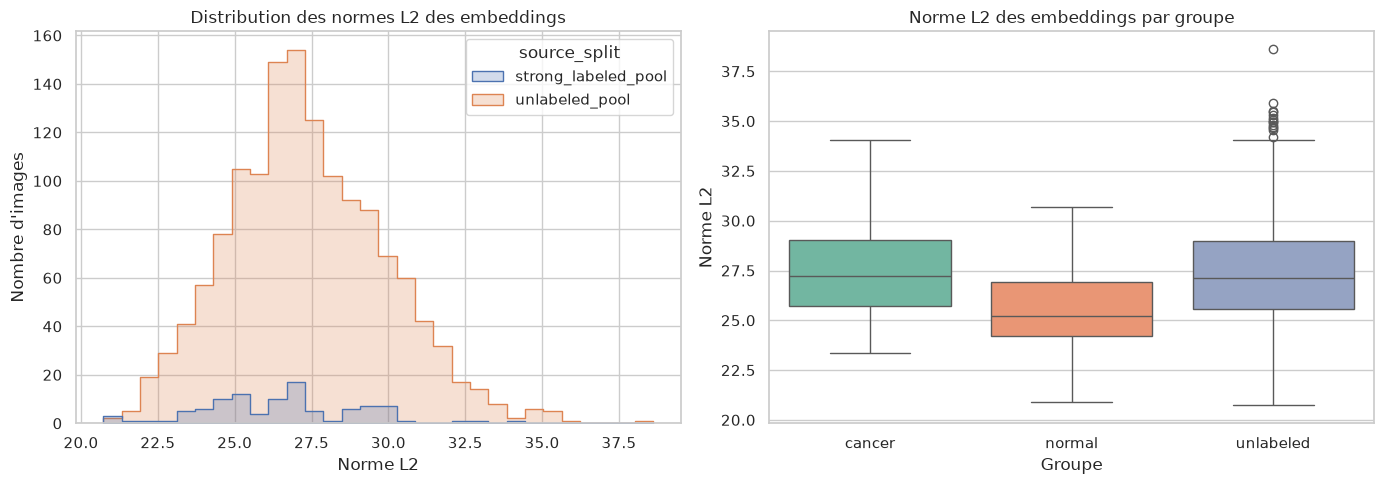

In [11]:
boxplot_order = ["cancer", "normal", "unlabeled"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(
    data=feature_table_df,
    x="embedding_l2_norm",
    hue="source_split",
    bins=30,
    element="step",
    common_norm=False,
    ax=axes[0],
)
axes[0].set_title("Distribution des normes L2 des embeddings")
axes[0].set_xlabel("Norme L2")
axes[0].set_ylabel("Nombre d'images")

sns.boxplot(
    data=feature_table_df,
    x="label_group",
    y="embedding_l2_norm",
    order=boxplot_order,
    ax=axes[1],
    palette="Set2",
)
axes[1].set_title("Norme L2 des embeddings par groupe")
axes[1].set_xlabel("Groupe")
axes[1].set_ylabel("Norme L2")

plt.tight_layout()
save_figure(fig, "02_feature_extraction_embedding_norms")
plt.show()


## 7. Export des artefacts

On sauvegarde ici trois artefacts principaux :

- la table complète de features ;
- les métadonnées seules ;
- la matrice NumPy des embeddings.

Un fichier de configuration JSON est également exporté pour tracer les paramètres de l'extraction.

In [12]:
feature_table_path = FEATURE_OUTPUT_DIR / f"{MODEL_NAME}_feature_table.csv"
metadata_path = FEATURE_OUTPUT_DIR / f"{MODEL_NAME}_embedding_metadata.csv"
embedding_path = FEATURE_OUTPUT_DIR / f"{MODEL_NAME}_embeddings.npy"
summary_path = FEATURE_OUTPUT_DIR / f"{MODEL_NAME}_feature_overview.csv"
run_config_path = FEATURE_OUTPUT_DIR / f"{MODEL_NAME}_run_config.json"

run_config = {
    "model_name": MODEL_NAME,
    "weights": str(WEIGHTS),
    "image_size": list(IMAGE_SIZE),
    "batch_size": BATCH_SIZE,
    "num_workers": NUM_WORKERS,
    "device": str(DEVICE),
    "feature_dim": FEATURE_DIM,
    "n_images": int(len(feature_table_df)),
    "elapsed_seconds": round(float(elapsed_seconds), 4),
}

if SAVE_FEATURE_TABLE:
    feature_table_df.to_csv(feature_table_path, index=False)
    embedding_metadata_df.to_csv(metadata_path, index=False)
    feature_overview_df.to_csv(summary_path, index=False)
    np.save(embedding_path, embedding_array)
    run_config_path.write_text(json.dumps(run_config, indent=2, ensure_ascii=False))

artifact_df = pd.DataFrame(
    {
        "artifact": [
            "feature_table_csv",
            "embedding_metadata_csv",
            "embedding_array_npy",
            "feature_overview_csv",
            "run_config_json",
        ],
        "path": [
            str(feature_table_path),
            str(metadata_path),
            str(embedding_path),
            str(summary_path),
            str(run_config_path),
        ],
    }
)

display(artifact_df)


,artifact,path
0,feature_table_csv,/home/maxime/projects/brainscan-semisupervised...
1,embedding_metadata_csv,/home/maxime/projects/brainscan-semisupervised...
2,embedding_array_npy,/home/maxime/projects/brainscan-semisupervised...
3,feature_overview_csv,/home/maxime/projects/brainscan-semisupervised...
4,run_config_json,/home/maxime/projects/brainscan-semisupervised...


## 8. Observations et suite

### Ce que produit cette étape

Cette étape construit une représentation vectorielle homogène de chaque image du corpus à partir d'un modèle pré-entraîné. Chaque image est ainsi décrite par un embedding dense de dimension fixe, directement exploitable par les méthodes de réduction de dimension et de clustering.

### Choix techniques retenus pour cette première version

- Les images sont conservées en `RGB` afin de rester compatibles avec un modèle pré-entraîné ImageNet.
- Le modèle choisi est `ResNet18`, plus léger qu'un `ResNet50` et suffisant pour une première exploration rapide.
- La tête de classification est supprimée pour ne conserver que la représentation visuelle apprise.
- Les paramètres sont gelés : il s'agit ici d'une extraction de features, pas encore d'un fine-tuning supervisé.

### Précautions méthodologiques pour l'étape 3

Même si les embeddings sont extraits pour l'ensemble du corpus, les usages devront rester séparés :

- les labels forts serviront à évaluer la qualité du clustering avec l'ARI ;
- les données non annotées resteront sans label fort ;
- les futurs labels faibles devront être stockés dans une colonne distincte pour éviter toute confusion.

### Pistes de comparaison possibles ensuite

Pour une itération ultérieure, on pourra comparer :

- `ResNet18` vs `ResNet50` ;
- un simple `resize` vs un preprocessing plus spécialisé ;
- les embeddings extraits sur la dernière couche vs une couche intermédiaire.

Le prochain notebook pourra maintenant charger `resnet18_feature_table.csv` pour appliquer PCA, UMAP ou t-SNE, puis tester plusieurs méthodes de clustering.